In [1]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


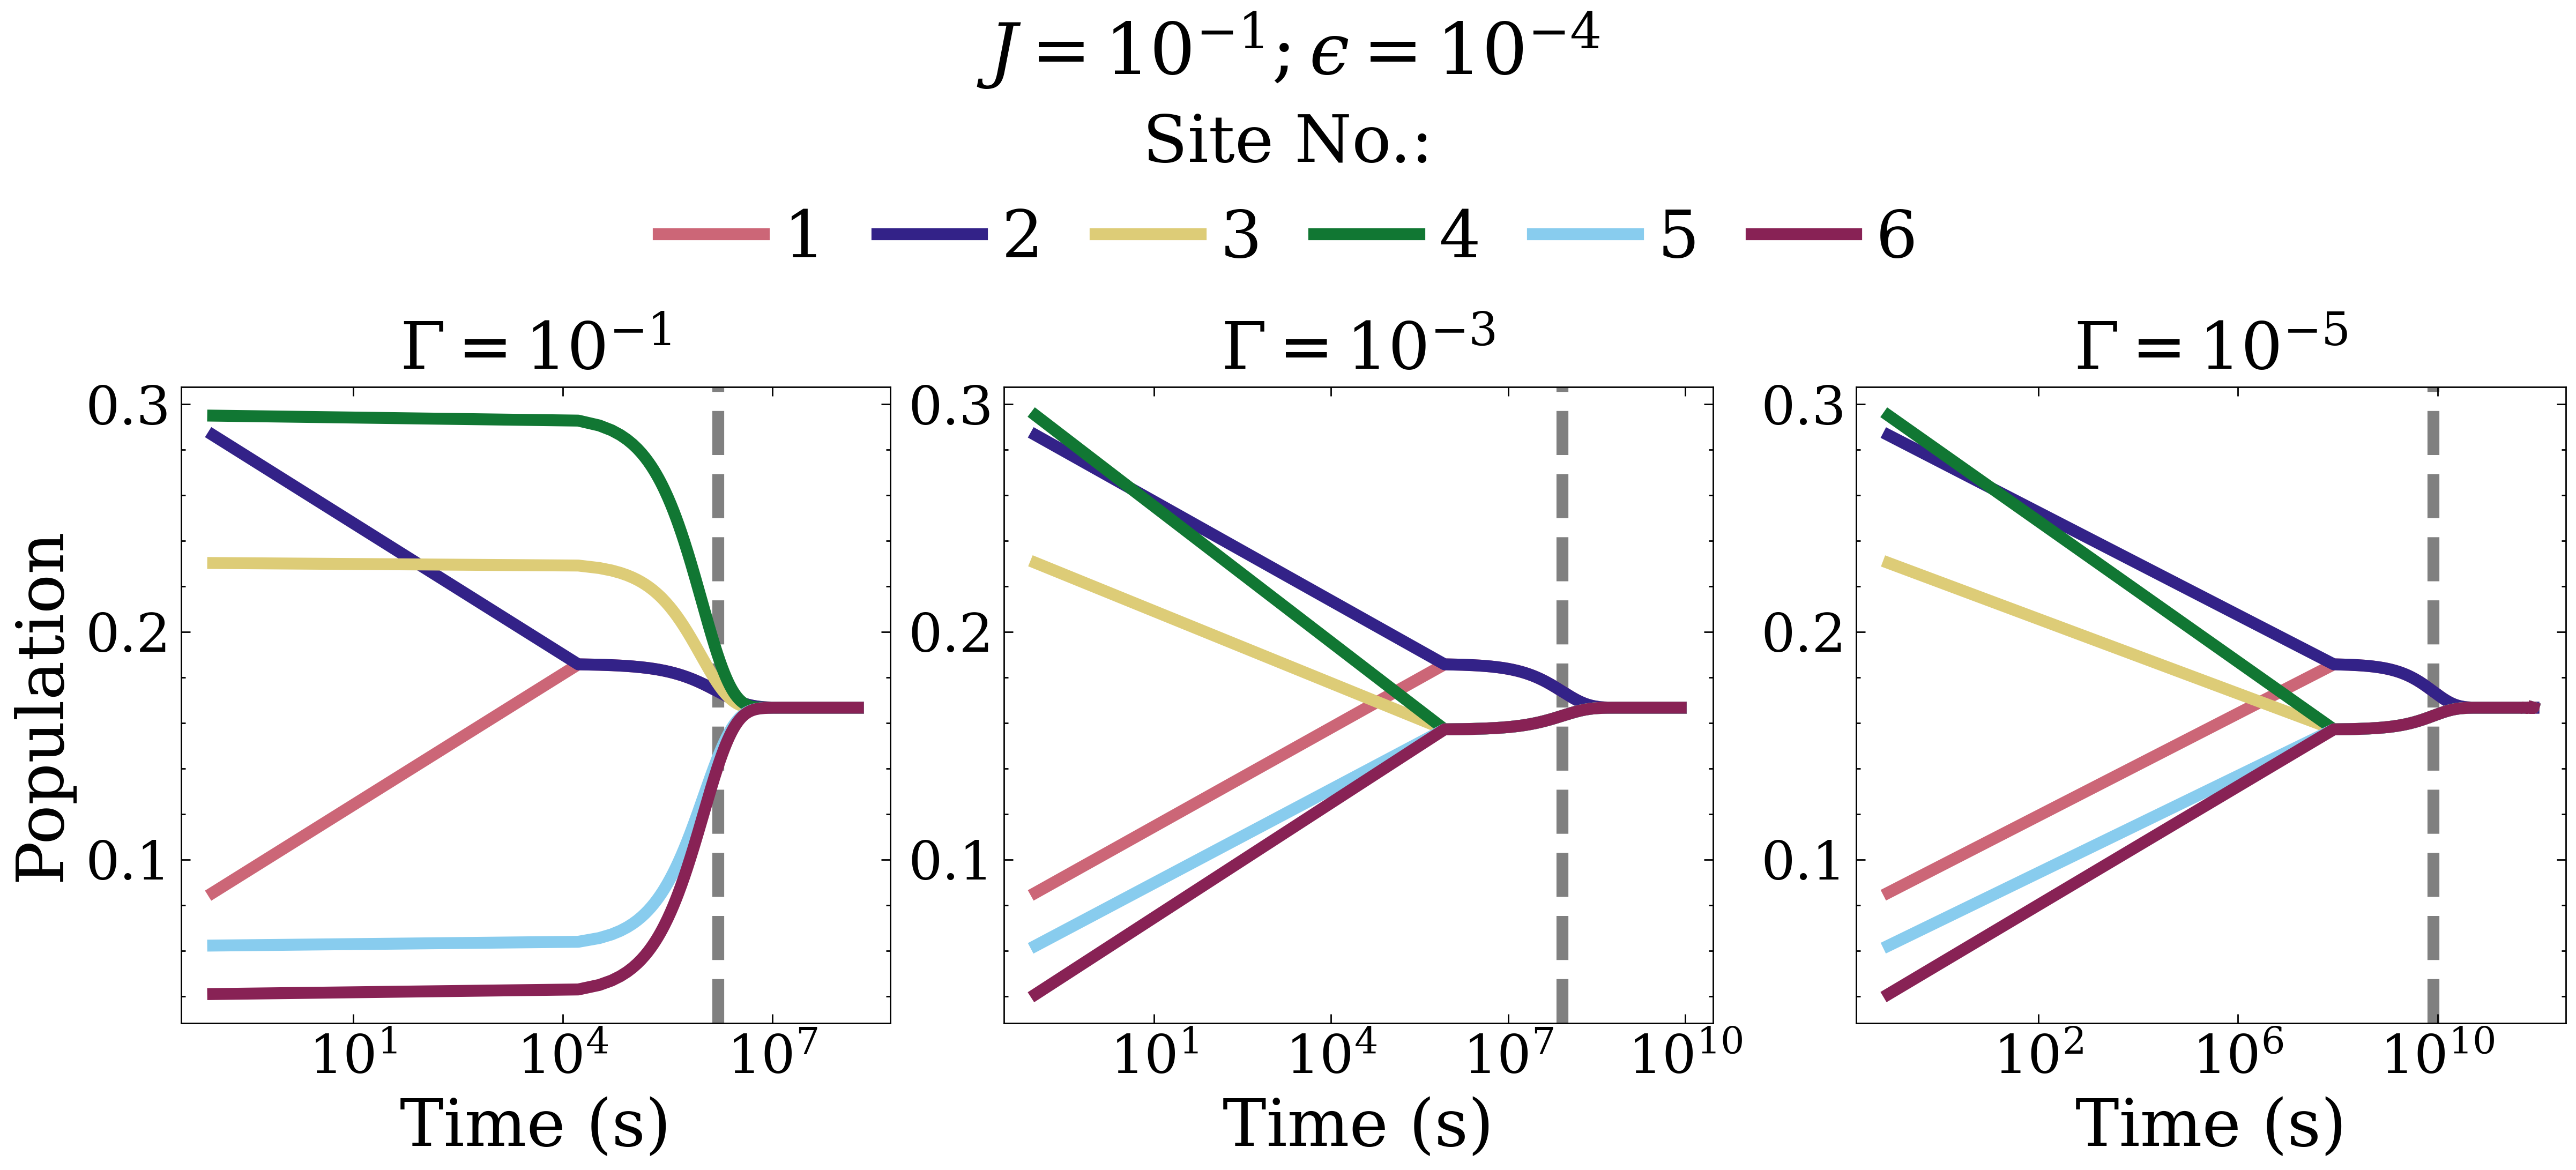

In [7]:
J_val = 0.1
epsilon_val = 1e-4
N=6


datas = [
    np.loadtxt("L_N=6;seed=31;J=10^-1;epsilon=10^-4;gamma=0.1.csv", dtype=np.complex128, delimiter=","),
    np.loadtxt("L_N=6;seed=31;J=10^-1;epsilon=10^-4;gamma=0.001.csv", dtype=np.complex128, delimiter=","),
    np.loadtxt("L_N=6;seed=31;J=10^-1;epsilon=10^-4;gamma=1e-05.csv", dtype=np.complex128, delimiter=","),
]
gammas = [
    1e-1,
    1e-3,
    1e-5,
]

#plt.style.use(['science', f'discrete-rainbow-{N}'])
plt.style.use(['science', 'muted'])

plt.rcParams.update({
    "text.usetex": False,
    # General font
    "font.weight": "medium",
    "font.size": 22,
    # Axes
    "axes.labelsize": 22,
    "axes.labelweight": "medium",
    "axes.titlesize": 22,
    "axes.titleweight": "medium",
    # Ticks
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    # Legend
    "legend.fontsize": 22,
    "legend.title_fontsize": 22,
    # Figure
    "figure.titlesize": 24
})
fig, axs = plt.subplots(1,3, figsize=(12, 4), layout='constrained')






        
for col, data in enumerate(datas):
    times = data[:, 0]
    rhos = data[:, 1:]

    lambdal = 2*N*gammas[col]*epsilon_val**2 / ( gammas[col]**2 + J_val**2 )
    
    for i in range(rhos.shape[1]//2): # skipping every other row, since we only want the real parts
        axs[col].plot(times,
                       np.abs(rhos[:, 2*i]),
                        label=f"{i+1}",
                        linewidth=4,
                        #alpha=1*0.9**i,
                        #linestyle="--"
                     )
    #axs[col].legend(title='Eigenvalue No.:', 
    #                #title_fontsize=12, 
    #                #fontsize=12, 
    #                ncol=3, 
    #                loc=(0.33, 0.06),
    #                columnspacing=0.5,
    #                handletextpad=0.3,
    #                handlelength=1.0,
    #                borderpad=0.4,
    #                labelspacing=0.3
    #               ) # plotting legend

    axs[col].set_xscale('log') # setting log scale for x axis
    #axs[col].invert_xaxis() # inverting x axis
    #axs[col].ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # using sci notation for y axis
    #axs[col].set_ylim([-1*gamma_val*0.2, gamma_val*1.2]) # forcing bounds of y axis (so that large magnitudes don't blow up the plot)
    axs[col].set_title(fr'$\Gamma=10^{{{int(np.log10(gammas[col]))}}}$')
    axs[col].set_xlabel("Time (s)")
    axs[col].axvline(1/lambdal,linestyle="--", color="gray", zorder=-1,linewidth=4)

axs[0].set_ylabel(r'Population')  # labelling y axis
   





fig.suptitle(fr'$J=10^{{{int(np.log10(J_val))}}}; ϵ=10^{{{int(np.log10(epsilon_val))}}}$',y=1.35)

handles, labels = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title='Site No.:',
    ncol=9,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.3),
    columnspacing=0.8,
    handletextpad=0.3,
    handlelength=1.6,
    borderpad=0.4,
)


fig.savefig("manysite_dynamics.pdf") 
fig.savefig("manysite_dynamics.svg") 